# General data and metadata overview

# Importing necessary packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Input

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
preprocessed_dir = Path(config['preprocessed_dir'])
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

# Load and Concatenate the Anndata objects


In [14]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Plot the ROIs distribution

In [15]:
long_short_count = adata.obs.loc[:,["patient_ID", "outcome_group",  "exp_name", "site"]].drop_duplicates().sort_values(by="patient_ID")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/319642204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = long_short_count.groupby(["outcome_group", "patient_ID"]).size().unstack()


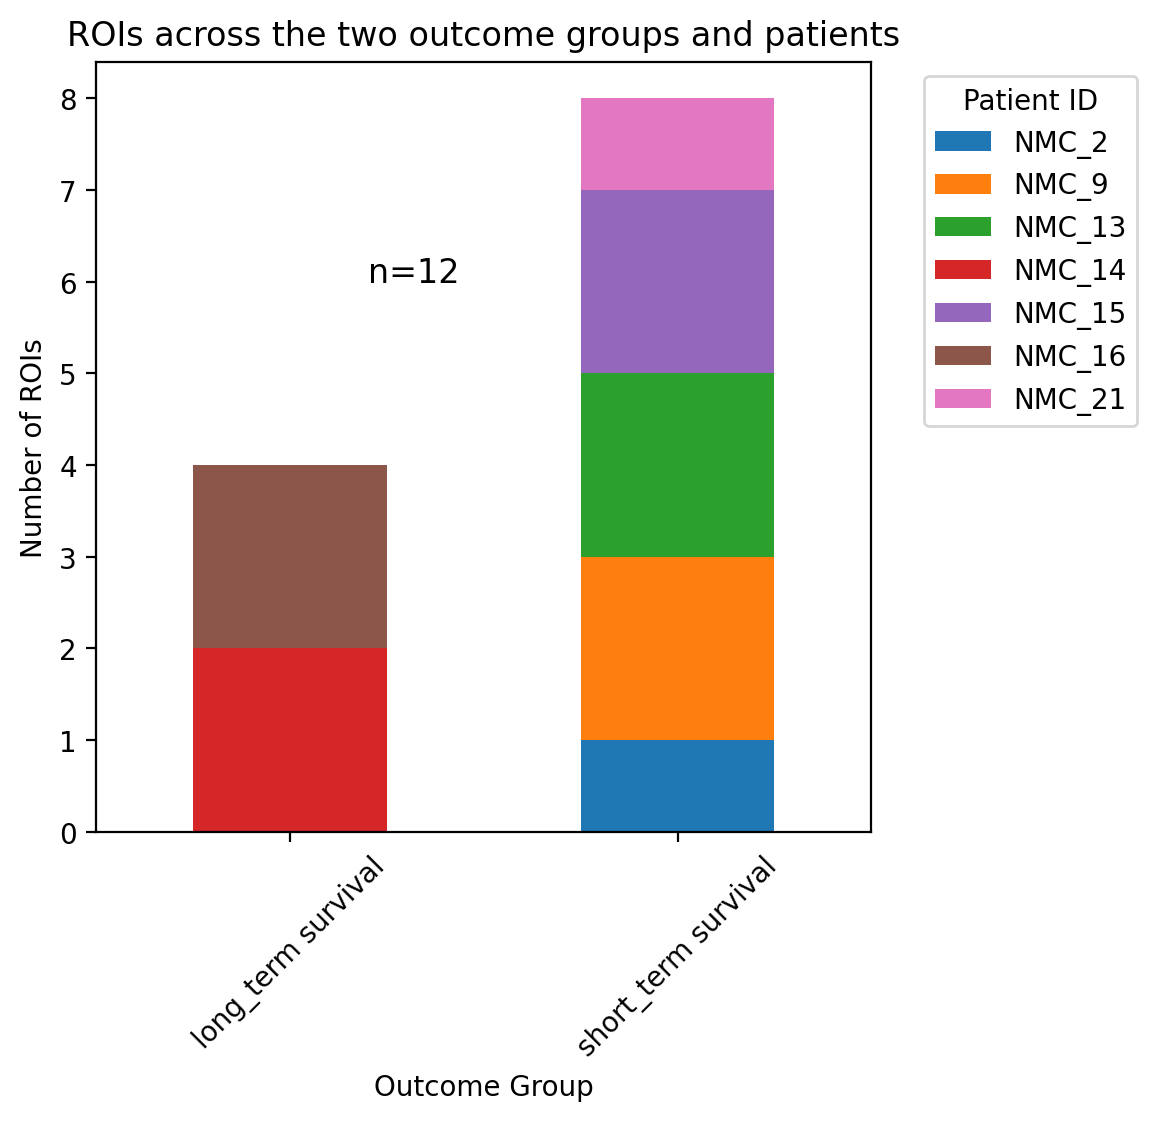

In [16]:
counts = long_short_count.groupby(["outcome_group", "patient_ID"]).size().unstack()
#Plot the number of long vs short_term survivals now 
category_colors = {
    'NMC_2': '#1f77b4',   # Blue
    'NMC_9': '#ff7f0e',   # Orange
    'NMC_13': '#2ca02c',  # Green
    'NMC_14': '#d62728',  # Red
    'NMC_15': '#9467bd',  # Purple
    'NMC_16': '#8c564b',  # Brown
    'NMC_21': '#e377c2'   # Pink
}

#Plot the number of long vs short_term survivals now
plt.figure(figsize=(5,5))
counts.plot(kind='bar', stacked=True, color = category_colors, ax=plt.gca())
plt.ylabel('Number of ROIs')
plt.xlabel('Outcome Group')
plt.title('ROIs across the two outcome groups and patients')
plt.legend(title="Patient ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
#make x-axis text smaller 
plt.xticks(fontsize=10)
#place the on the plot n=12
plt.text(0.2, 6, 'n=12', fontsize=12)
#remove grid lines from the plot
plt.grid(False)
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/3634410928.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = long_short_count.groupby(["outcome_group", "site"]).size().unstack()


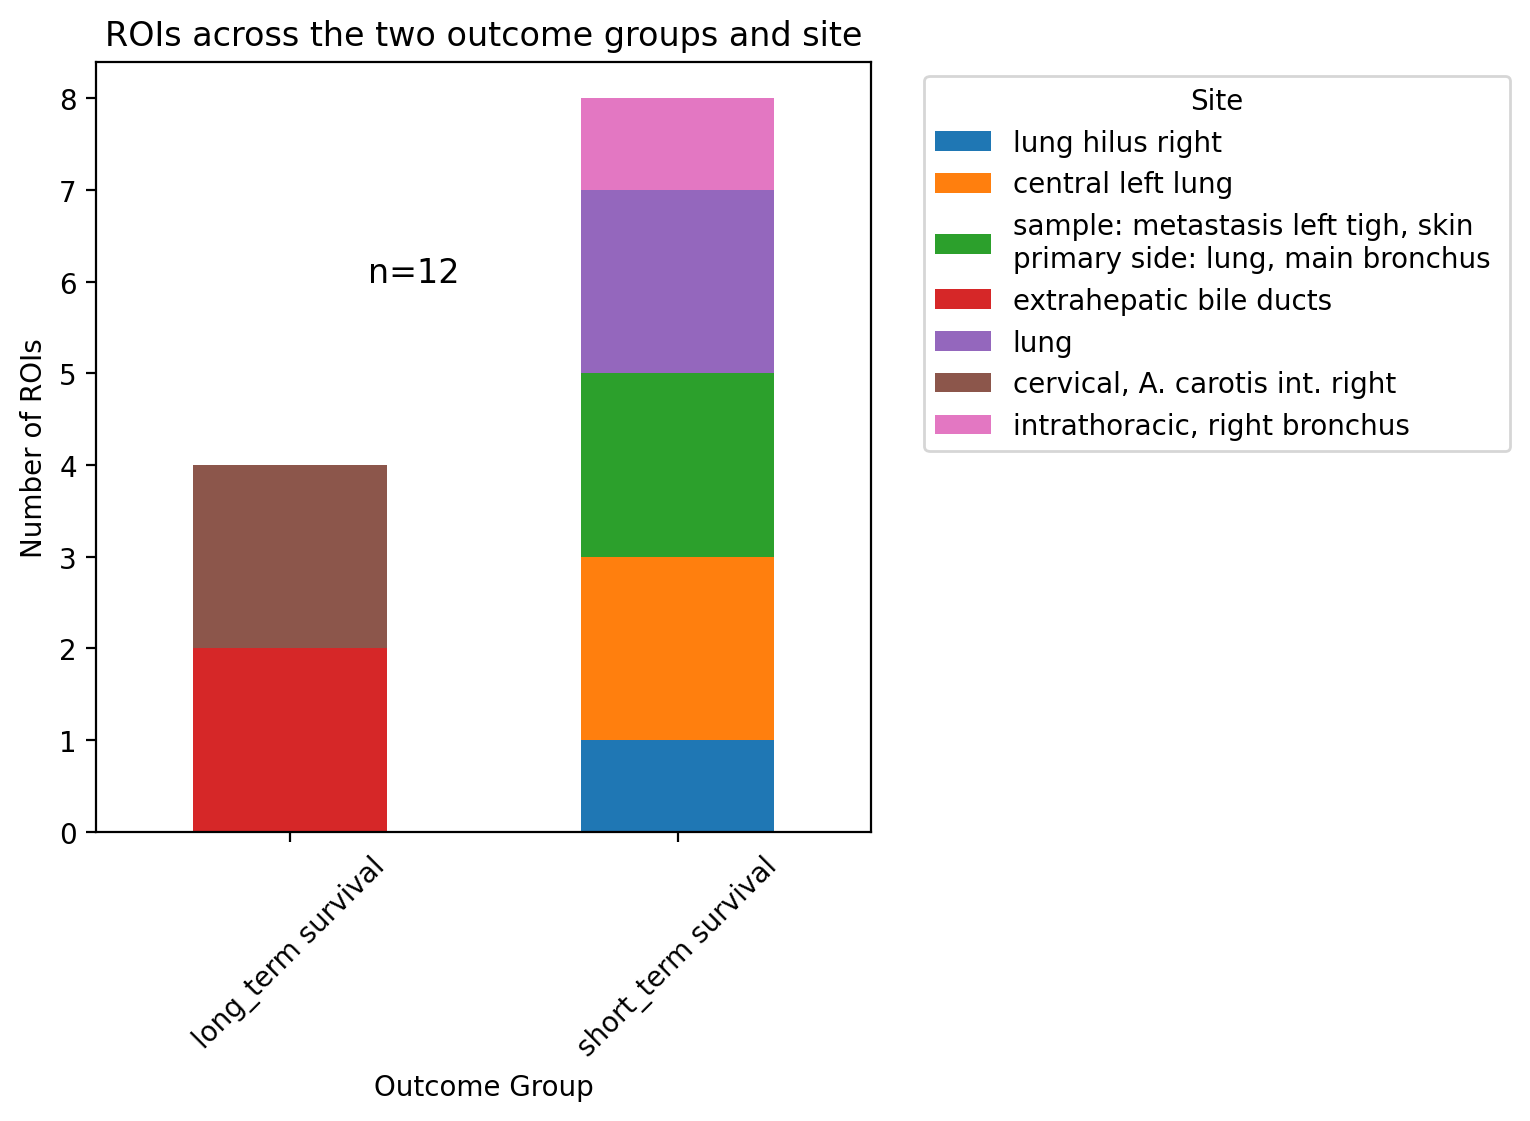

In [17]:
#Plot the tissue bar chart based on the outcome group
counts = long_short_count.groupby(["outcome_group", "site"]).size().unstack()
custom_order = ['lung hilus right', 'central left lung ', 'sample: metastasis left tigh, skin \nprimary side: lung, main bronchus ', 'extrahepatic bile ducts', 'lung', 'cervical, A. carotis int. right', 'intrathoracic, right bronchus']
counts = counts[custom_order]
category_colors = {
    'lung hilus right': '#1f77b4',   # Blue
    'central left lung ': '#ff7f0e',   # Orange
    'sample: metastasis left tigh, skin \nprimary side: lung, main bronchus ': '#2ca02c',  # Green
    'extrahepatic bile ducts': '#d62728',  # Red
    'lung': '#9467bd',  # Purple
    'cervical, A. carotis int. right': '#8c564b',  # Brown
    'intrathoracic, right bronchus': '#e377c2'   # Pink
}
plt.figure(figsize=(5,5))
counts.plot(kind="bar", stacked=True, color = category_colors, ax=plt.gca())
plt.legend(title="Site", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylabel("Number of ROIs") 
plt.xlabel("Outcome Group")
plt.xticks(rotation=45)
plt.text(0.2, 6, 'n=12', fontsize=12)
plt.xticks(fontsize=10)
plt.title("ROIs across the two outcome groups and site")
plt.grid(False)
plt.show()

# Plot the Cell type distribution

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/2638582728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_exp = adata.obs.groupby(["exp_name", "cell_type"]).size().unstack()
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/2638582728.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_outcome = adata.obs.groupby(["outcome_group", "cell_type"]).size().unstack()
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/2638582728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass

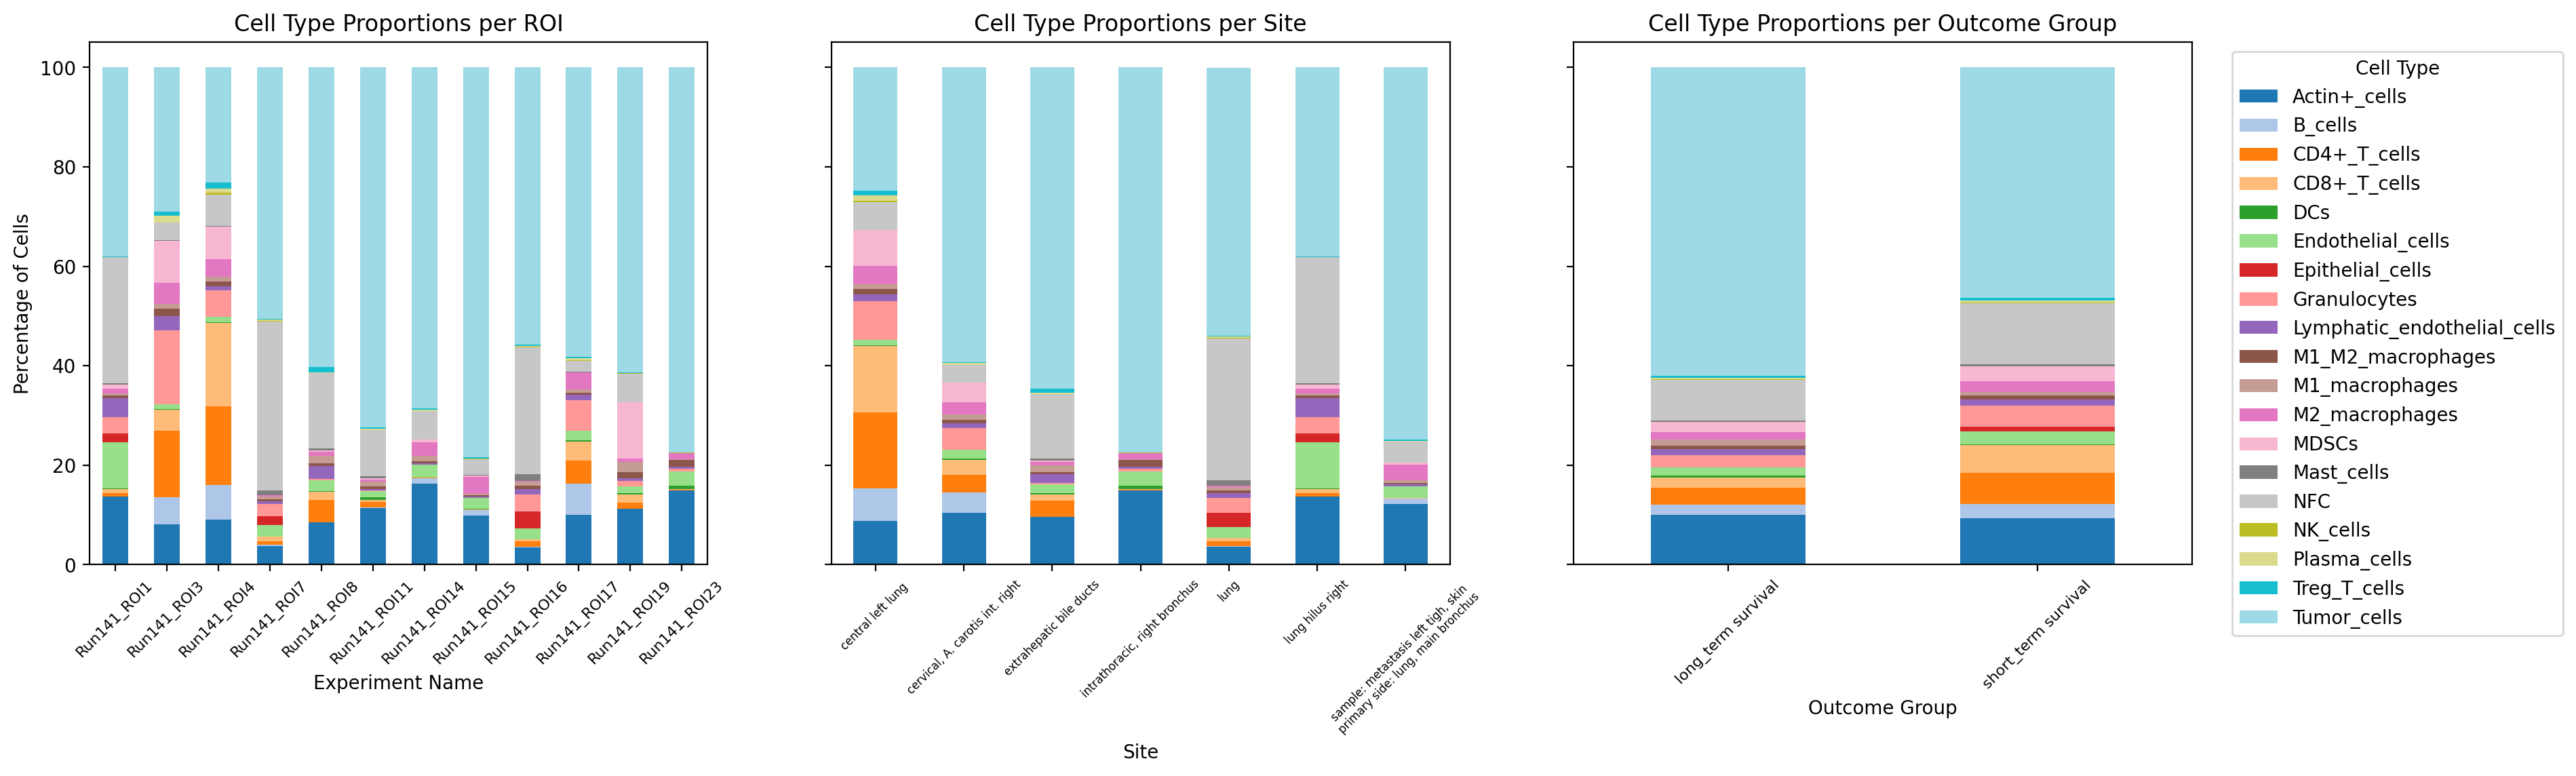

In [18]:
#calculate cell type proportions per ROI
counts_exp = adata.obs.groupby(["exp_name", "cell_type"]).size().unstack()
counts_exp = counts_exp.div(counts_exp.sum(axis=1), axis=0).mul(100).round(2)
#calculate cell type proportions per outcome group
counts_outcome = adata.obs.groupby(["outcome_group", "cell_type"]).size().unstack()
counts_outcome = counts_outcome.div(counts_outcome.sum(axis=1), axis=0).mul(100).round(2)
#calculate cell type proportiosn per site
counts_site = adata.obs.groupby(["site", "cell_type"]).size().unstack()
counts_site = counts_site.div(counts_site.sum(axis=1), axis=0).mul(100).round(2)
#plot the cell type proportions per ROI, outcome group, and site
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
counts_exp.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_ylabel("Percentage of Cells")
axes[0].set_xlabel("Experiment Name")
axes[0].set_title("Cell Type Proportions per ROI")
#remove legend of firt plot
axes[0].legend().set_visible(False)
axes[0].grid(False)
axes[0].tick_params(axis='x', labelsize=8, rotation = 45)
counts_site.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_ylabel("Percentage of Cells")
axes[1].set_xlabel("Site")
axes[1].set_title("Cell Type Proportions per Site")
axes[1].legend().set_visible(False)
axes[1].grid(False)
axes[1].tick_params(axis='x', labelsize=6, rotation = 45)
counts_outcome.plot(kind="bar", stacked=True, ax=axes[2], colormap="tab20")
axes[2].set_ylabel("Percentage of Cells")
axes[2].set_xlabel("Outcome Group")
axes[2].set_title("Cell Type Proportions per Outcome Group")
axes[2].legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[2].grid(False)
axes[2].tick_params(axis='x', labelsize=8, rotation = 45)
plt.show()

# Group the Tissues

In [19]:
conditions = [adata.obs["site"].isin(["lung", "lung hilus right", "central left lung ", "intrathoracic, right bronchus"]), 
              adata.obs["site"].str.contains("extrahepatic"), 
              adata.obs["site"].str.contains("cervical"),
              adata.obs["site"] == "sample: metastasis left tigh, skin \nprimary side: lung, main bronchus "]
outcome = ["Lung", "Bile", "Cervix", "Skin"]
adata.obs["tissue"] = np.select(conditions, outcome, default="Other")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4019/2620656629.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_tissue = adata.obs.groupby(["tissue", "cell_type"]).size().unstack().fillna(0)


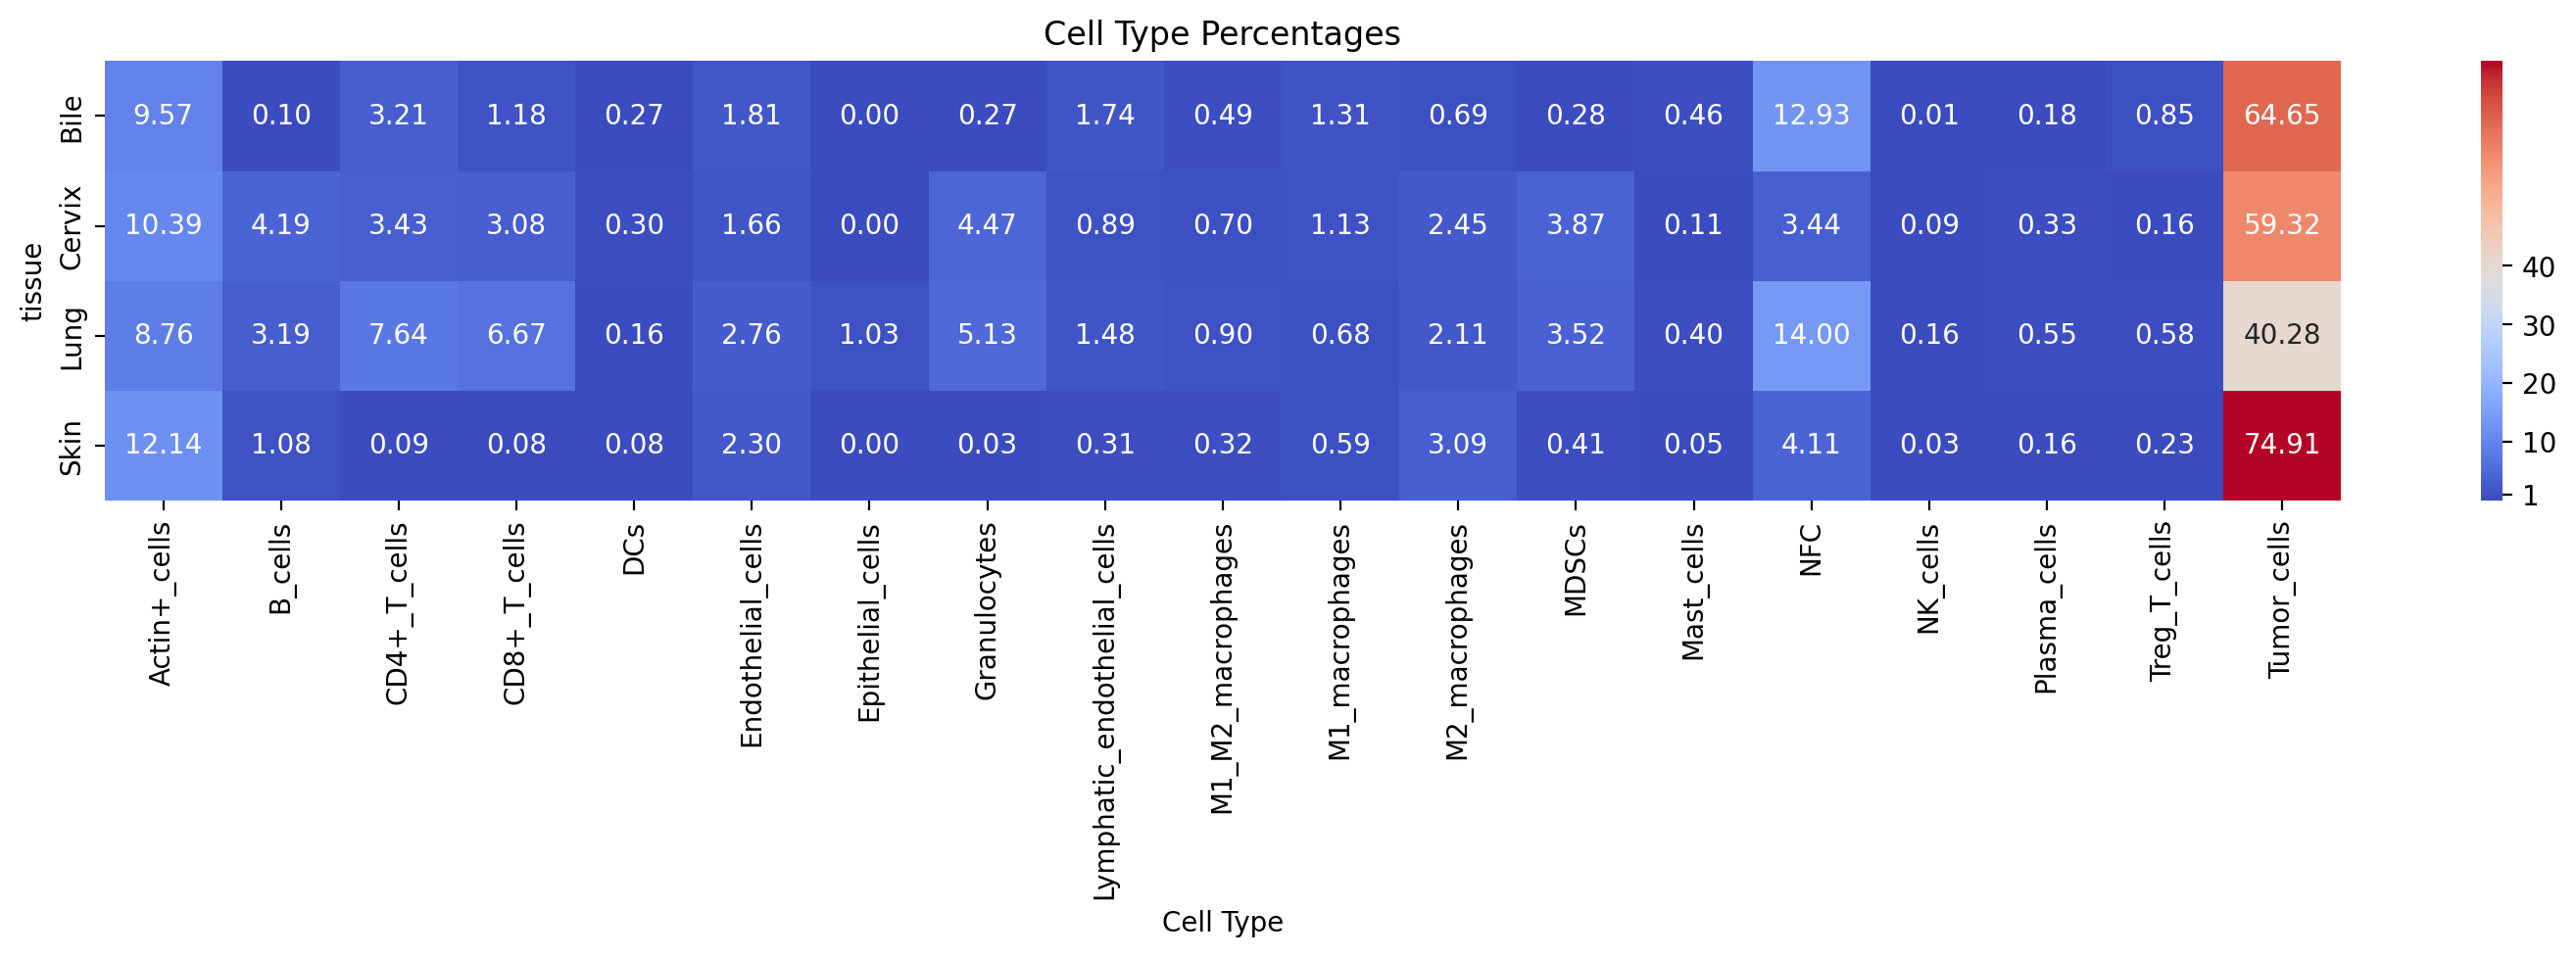

In [20]:
#heatmap for cell type proportions
counts_tissue = adata.obs.groupby(["tissue", "cell_type"]).size().unstack().fillna(0)
counts_tissue = counts_tissue.div(counts_tissue.sum(axis=1), axis=0).mul(100).round(2)
plt.figure(figsize=(15, 5))
#create custom bin for legend
bins = [1, 10, 20, 30, 40]  # Custom thresholds
cmap = sns.color_palette("coolwarm", len(bins) - 1)
sns.heatmap(counts_tissue, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"ticks": bins})
#make the x-axis labels at 45 degrees
# plt.ylabel("Tissue")
plt.xlabel("Cell Type")
plt.title("Cell Type Percentages")
plt.tight_layout()